# ERA5 GEV Fit Spatial Maps

This notebook visualizes the spatial distributions and temporal trends of non-stationary Generalized Extreme Value (GEV) parameters fitted to ERA5 annual temperature extremes. It generates global maps showing the location (μ), scale (σ), and shape (ξ) parameters along with their temporal trends, providing insights into how temperature extremes and their variability are changing across the globe. The analysis covers both annual maximum and minimum temperatures at 1-degree resolution, computed relative to different anomaly types (raw data, anomalies relative to warming trend, anomalies relative to annual mean temperature).

In [1]:
# import base packages for data analysis
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# config
from evt_heat_waves.config import ERA5_PATH, FIGS_PATH

# import custom stuff
from evt_heat_waves.plotting.plotting_presets import get_presets
from evt_heat_waves.plotting.gev_param_plots import plot_gev_parameters, print_summary

presets, _ = get_presets(markers=False)
plt.rcParams.update(presets)

save_figs = True

In [5]:
TMIN = 1979  # minimum year for included data
GRID = '1deg'  # grid size
ex_type = 'max'  # 'max' or 'min'
fit = 'nonstat_only_loc_trend'  # fit type from config/mle_attrs.yaml
anom_type = 'raw'  # 'raw', 'trend', or 'annmean'

# import data
ds = xr.open_dataset(ERA5_PATH / 'gev' / f'era5_t2m_annual_{ex_type}_{GRID}_landonly_gev_{fit}_TMIN{TMIN}_{anom_type}.nc', engine='netcdf4')

In [6]:
ds

<xarray.Dataset>
Dimensions:           (year: 46, lat: 180, lon: 360)
Coordinates:
  * lat               (lat) float64 -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * lon               (lon) int64 0 1 2 3 4 5 6 ... 353 354 355 356 357 358 359
  * year              (year) int64 1979 1980 1981 1982 ... 2021 2022 2023 2024
Data variables:
    t2m               (year, lat, lon) float32 ...
    t2m_anom_annmean  (year, lat, lon) float32 ...
    t2m_anom_trend    (year, lat, lon) float64 ...
    loc_raw           (lat, lon) float64 ...
    se_loc_raw        (lat, lon) float64 ...
    loc_t_raw         (lat, lon) float64 ...
    se_loc_t_raw      (lat, lon) float64 ...
    scale_raw         (lat, lon) float64 ...
    se_scale_raw      (lat, lon) float64 ...
    shape_raw         (lat, lon) float64 ...
    se_shape_raw      (lat, lon) float64 ...
Attributes:
    MLE_success_rate:  0.9408224674022067

Figure saved to: /project/bbcael/ambauer/gev-heat-waves/analysis/figs/analysis/2026-05-13-era5-t2m-max-raw-gev-nonstat-parameters-1deg-1979.png


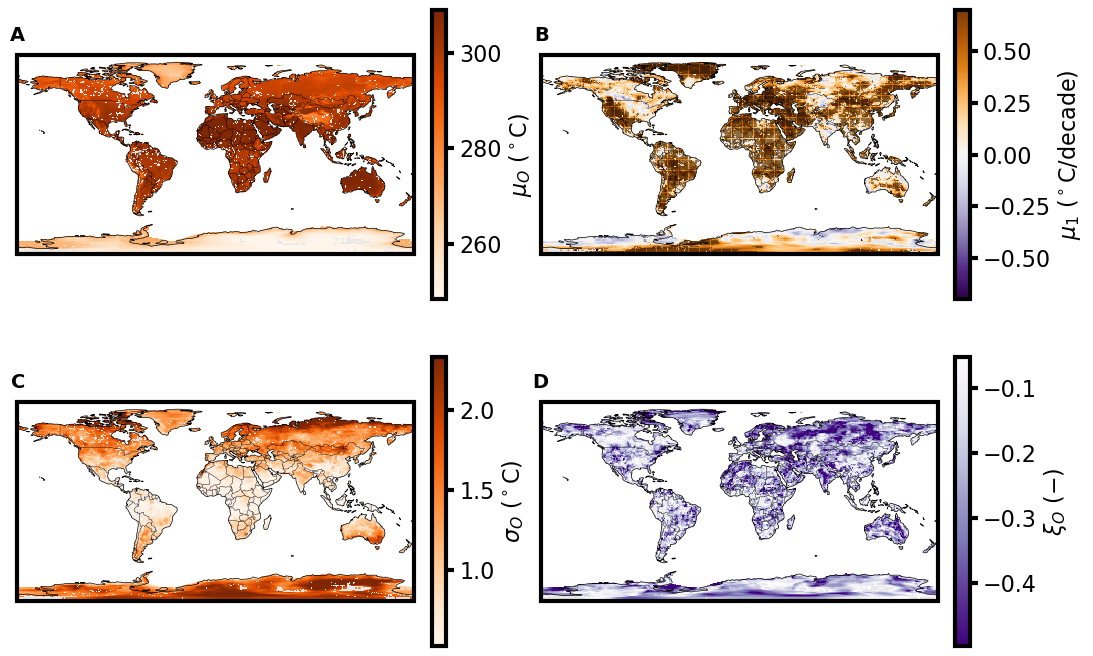

In [ ]:
plot_gev_parameters(ds, fit=fit, anom_type=anom_type, save_figs=save_figs,
                    fname=f'era5-t2m-max-{anom_type}-gev-parameters-{GRID}-{TMIN}', output_dir=FIGS_PATH)

In [5]:
print_summary(ds, fit=fit, anom_type=anom_type)

 ---- FOR annmean AND MAXIMUM TEMPERATURES ----
The area weighted average for loc is 14.267817935289331
The area weighted average for loc_t is -0.2080679784738806
The area weighted average for scale is 1.120747623987298
The area weighted average for shape is -0.24973709037395136
